In [193]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from itertools import product
import os

In [194]:
!pip install ucimlrepo

In [195]:
RANDOM_STATE = 42

In [196]:
DATA_FOLDER = "data"
PATH = f"{DATA_FOLDER}/bank_marketing.csv"
SEP = ";"

if os.path.isfile(PATH):
    df = pd.read_csv(PATH, sep=SEP)
    X = df.drop(df.columns[-1], axis=1)
    y = df.drop(df.columns[:-1], axis=1)
else:
    from ucimlrepo import fetch_ucirepo
    bank_marketing = fetch_ucirepo(id=222)
    X = bank_marketing.data.features
    y = bank_marketing.data.targets
    df = X.join(y)
    os.makedirs(DATA_FOLDER, exist_ok=True)
    df.to_csv(PATH, sep=SEP, index=False)

In [197]:
X.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome'],
      dtype='object')

In [198]:
X

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,NaN
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,NaN
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,NaN


In [199]:
target = y.columns[0]

print(target)

y


In [200]:
y.value_counts()

,count
y,
no,39922
yes,5289


In [201]:
# This attribute highly affects the output targe. Yet, the duration is not known before a call is performed
X = X.drop("duration", axis=1)

In [202]:
X_encoded = pd.get_dummies(X, dtype=int, drop_first=True)
features = X_encoded.columns
print(features)

Index(['age', 'balance', 'day_of_week', 'campaign', 'pdays', 'previous',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'marital_married',
       'marital_single', 'education_secondary', 'education_tertiary',
       'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone',
       'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep', 'poutcome_other', 'poutcome_success'],
      dtype='object')


In [203]:
X_encoded

,age,balance,day_of_week,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success
0,58,2143,5,1,-1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
1,44,29,5,1,-1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,33,2,5,1,-1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
3,47,1506,5,1,-1,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,33,1,5,1,-1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,825,17,3,-1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
45207,71,1729,17,2,-1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
45208,72,5715,17,5,184,3,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
45209,57,668,17,4,-1,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [204]:
y_encoded = pd.get_dummies(y, dtype=int, drop_first=True)

In [205]:
y_encoded

,y_yes
0,0
1,0
2,0
3,0
4,0
...,...
45206,1
45207,1
45208,1
45209,0


In [206]:
X_values = X_encoded.values
y_values = y_encoded.values.ravel()

In [207]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer
from typing import Any

# Used for oob-score in RandomForest
def f1_macro(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return f1_score(y_true, y_pred, average="macro")

# Used in cross validation
f1_macro_scorer = make_scorer(f1_score, average="macro")

Estimator = Any

def cross_validation(estimator: Estimator, params: dict = None) -> tuple[int, int, list[Estimator]]:
    if params is None:
        params = {}

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    cv_result = cross_validate(
        estimator=estimator,
        X=X_values,
        y=y_values,
        scoring=f1_macro_scorer,
        return_train_score=True,
        return_estimator=True,
        cv=cv,
        params=params
    )

    return cv_result["train_score"].mean(), cv_result["test_score"].mean(), cv_result["estimator"]

In [208]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

decision_tree = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=3, class_weight="balanced")
decision_tree.fit(X_values, y_values)

DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=42)

In [209]:
from sklearn.tree import plot_tree

def visualize_tree(tree: DecisionTreeClassifier | DecisionTreeRegressor) -> None:
    plot_tree(
        decision_tree=tree,
        feature_names=features,
        fontsize=7,
        proportion=True,
        rounded=True,
    )

In [210]:
print(decision_tree.get_depth())

3


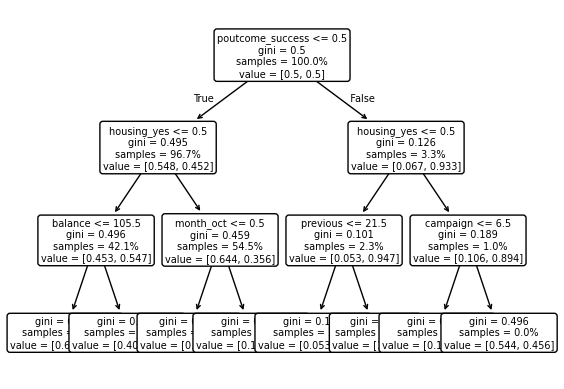

In [211]:
visualize_tree(decision_tree)

100%|██████████| 32/32 [01:04<00:00,  2.02s/it]


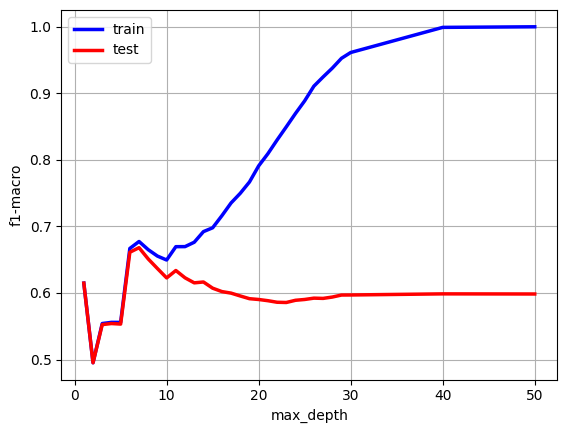

In [212]:
max_depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
              20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 40, 50]
train_scores = []
test_scores = []

for d in tqdm(max_depths):
    estimator = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=d, class_weight="balanced")
    train_score, test_score, _ = cross_validation(estimator)
    train_scores.append(train_score)
    test_scores.append(test_score)

plt.plot(max_depths, train_scores, label="train", color="blue", linewidth=2.5)
plt.plot(max_depths, test_scores, label="test", color="red", linewidth=2.5)
plt.grid(visible=True)
plt.xlabel("max_depth")
plt.ylabel("f1-macro")
plt.legend()
plt.show()

In [213]:
from sklearn.utils import compute_sample_weight

sample_weight = compute_sample_weight(
    class_weight='balanced',
    y=y_values
)

In [214]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting = GradientBoostingClassifier(random_state=RANDOM_STATE)
gradient_boosting.fit(X_values, y_values, sample_weight=sample_weight)

GradientBoostingClassifier(random_state=42)

In [215]:
feature_importances = gradient_boosting.feature_importances_

max_score = feature_importances.max()
for score, name in sorted(zip(feature_importances, features), reverse=True):
    if score > 0:
        print(f"{name:<30}{100 * (score / max_score):.2f}")

poutcome_success              100.00
housing_yes                   40.28
age                           34.51
pdays                         34.07
day_of_week                   21.21
balance                       20.16
month_mar                     15.15
campaign                      13.13
month_oct                     11.70
month_may                     11.62
marital_married               7.73
loan_yes                      6.97
month_feb                     4.99
month_sep                     4.45
education_tertiary            4.43
month_nov                     3.79
marital_single                3.48
month_jan                     2.52
previous                      2.26
month_jun                     2.16
month_jul                     2.13
month_aug                     1.68
month_dec                     1.59
job_entrepreneur              0.73
job_housemaid                 0.66
job_blue-collar               0.60
contact_telephone             0.51
job_services                  0.13
poutcome_

In [216]:
for i, (est, ) in enumerate(gradient_boosting.estimators_):
    print(f"{i:<20}{est}")

0                   DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                      random_state=RandomState(MT19937) at 0x7C8840DCE740)
1                   DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                      random_state=RandomState(MT19937) at 0x7C8840DCE740)
2                   DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                      random_state=RandomState(MT19937) at 0x7C8840DCE740)
3                   DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                      random_state=RandomState(MT19937) at 0x7C8840DCE740)
4                   DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                      random_state=RandomState(MT19937) at 0x7C8840DCE740)
5                   DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                      random_state=RandomState(MT19937) at 0x7C8840DCE740)
6                   DecisionTreeRegressor(criterion='friedman_ms

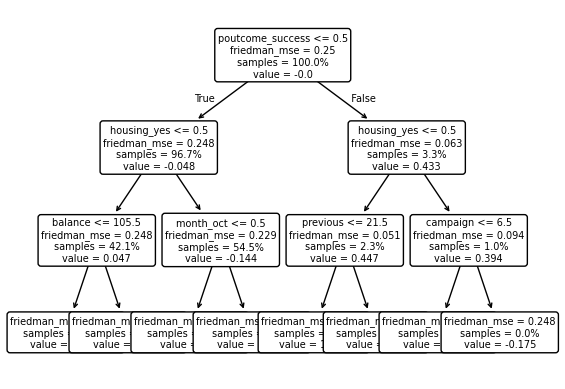

In [217]:
visualize_tree(gradient_boosting.estimators_[0][0])

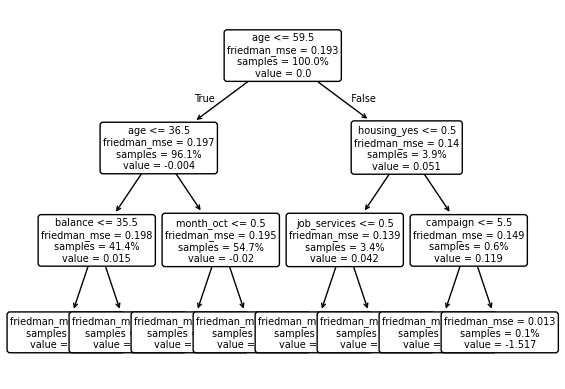

In [218]:
visualize_tree(gradient_boosting.estimators_[50][0])

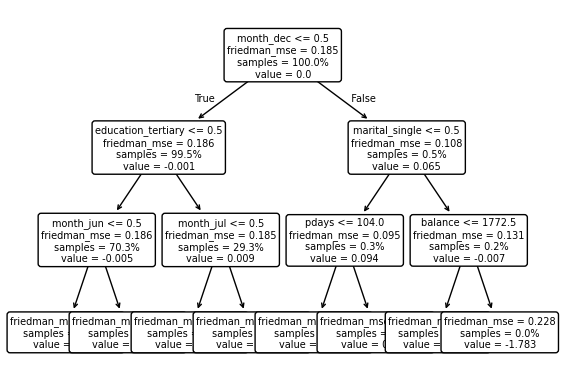

In [219]:
visualize_tree(gradient_boosting.estimators_[99][0])

100%|██████████| 84/84 [48:50<00:00, 34.88s/it] 


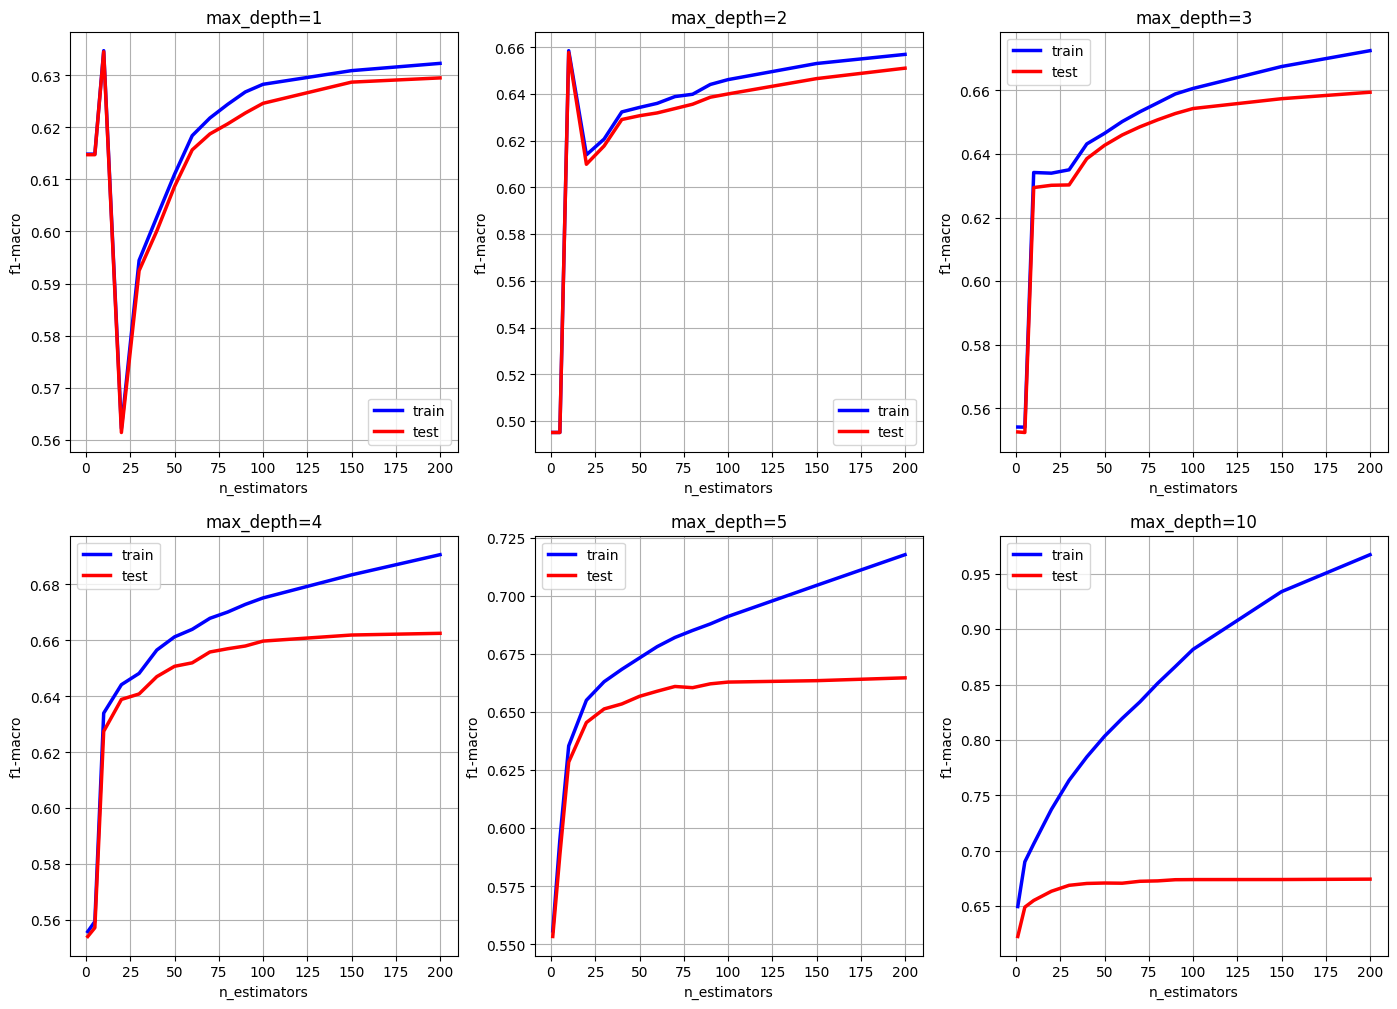

In [220]:
max_depths = [1, 2, 3, 4, 5, 10]
estimator_number = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200]

train_scores = {}
test_scores = {}

for d in max_depths:
    train_scores[d] = []
    test_scores[d] = []

for (d, n) in tqdm(list(product(max_depths, estimator_number))):
    estimator = GradientBoostingClassifier(random_state=RANDOM_STATE, max_depth=d, n_estimators=n)
    train_score, test_score, _ = cross_validation(estimator, params={"sample_weight": sample_weight})
    train_scores[d].append(train_score)
    test_scores[d].append(test_score)

fig, sub = plt.subplots(2, 3, figsize=(17,12))
for d, ax in zip(max_depths, sub.flatten()):
    ax.grid(visible=True)
    ax.plot(estimator_number, train_scores[d], label="train", color="blue", linewidth=2.5)
    ax.plot(estimator_number, test_scores[d], label="test", color="red", linewidth=2.5)
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("f1-macro")
    ax.set_title(f"max_depth={d}")
    ax.legend()
plt.show()

  0%|          | 0/84 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have 

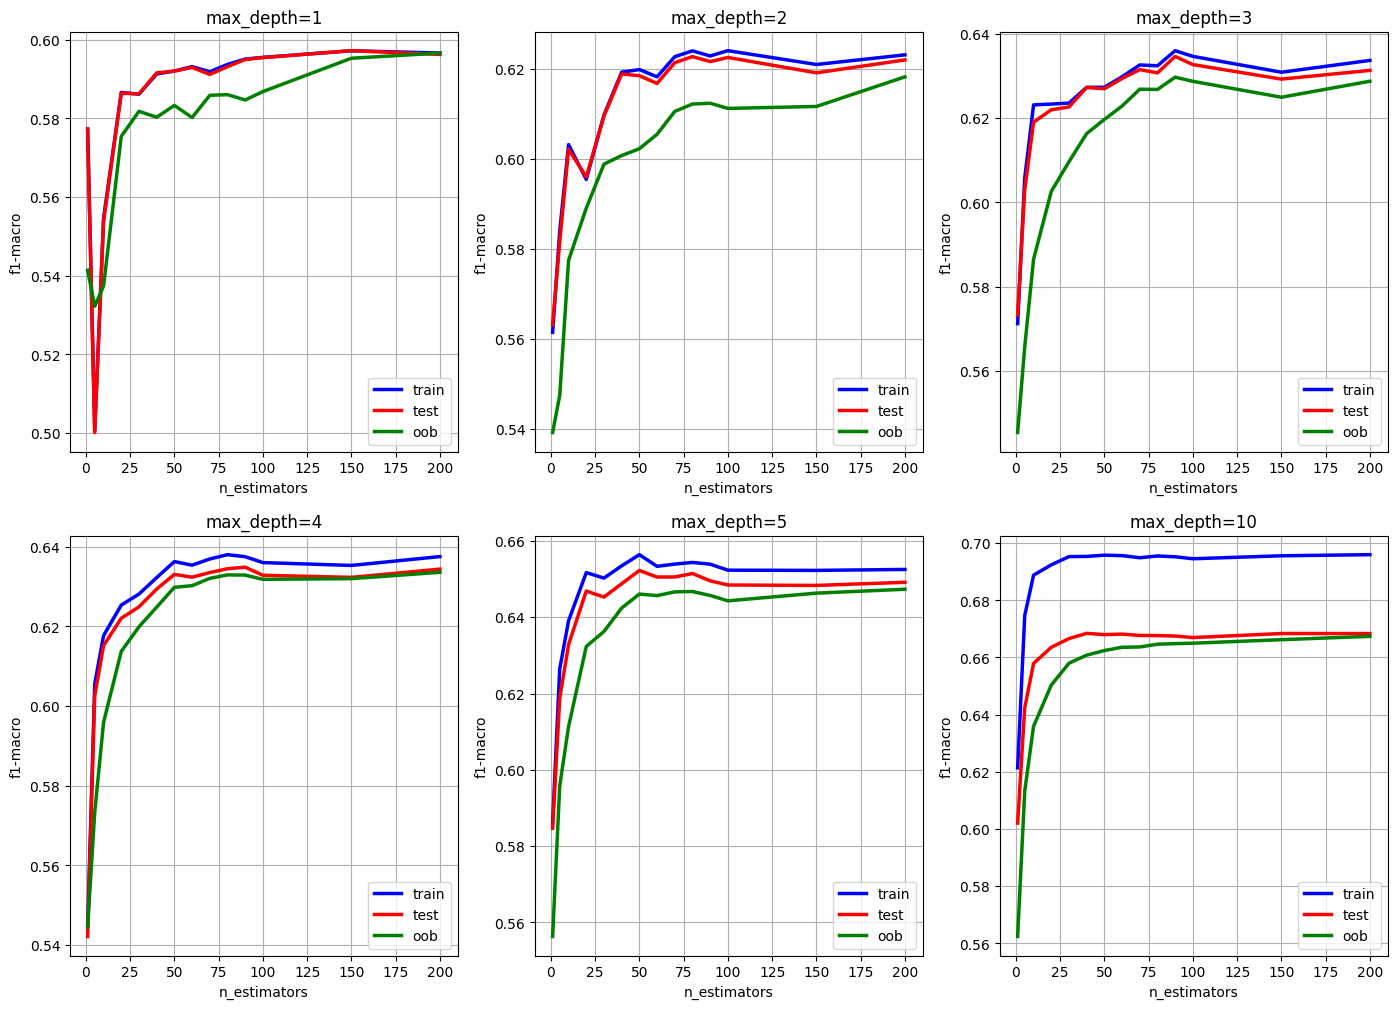

In [221]:
from sklearn.ensemble import RandomForestClassifier

max_depths = [1, 2, 3, 4, 5, 10]
estimator_number = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200]

train_scores = {}
test_scores = {}
oob_scores = {}

for d in max_depths:
    train_scores[d] = []
    test_scores[d] = []
    oob_scores[d] = []

for (d, n) in tqdm(list(product(max_depths, estimator_number))):
    estimator = RandomForestClassifier(
        random_state=RANDOM_STATE,
        max_depth=d,
        n_estimators=n,
        bootstrap=True,
        n_jobs=os.cpu_count(),
        oob_score=f1_macro,
        class_weight="balanced_subsample"
    )

    train_score, test_score, estimators = cross_validation(estimator)
    estimators_oob_score = np.array([e.oob_score_ for e in estimators])
    oob_score = estimators_oob_score.mean()

    train_scores[d].append(train_score)
    test_scores[d].append(test_score)
    oob_scores[d].append(oob_score)

fig, sub = plt.subplots(2, 3, figsize=(17,12))
for d, ax in zip(max_depths, sub.flatten()):
    ax.grid(visible=True)
    ax.plot(estimator_number, train_scores[d], label="train", color="blue", linewidth=2.5)
    ax.plot(estimator_number, test_scores[d], label="test", color="red", linewidth=2.5)
    ax.plot(estimator_number, oob_scores[d], label="oob", color="green", linewidth=2.5)
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("f1-macro")
    ax.set_title(f"max_depth={d}")
    ax.legend()
plt.show()